In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS
from sac.trainer import HockeyTrainer
from sac.tournament import PooledTournament

In [2]:
params = SB3_PARAMS
hidden_sizes = [256, 256]
params["alpha"] = 0.01
params["hidden_sizes"] = hidden_sizes

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/selfplay-{random_seed}"

In [6]:
trainer = HockeyTrainer(params)
weak_opponent = h_env.BasicOpponent(weak=True)
strong_opponent = h_env.BasicOpponent(weak=False)

In [7]:
tournament = PooledTournament(seed=random_seed)
tournament.add_agent(weak_opponent)
tournament.add_agent(strong_opponent)

In [8]:
trainer.warmup(256)

In [9]:
max_timesteps = 500
new_episodes = 500
log_interval = 20
train_interval = 20

In [26]:
def evaluate_agent(trainer, opponent):
    rewards, scores = trainer.evaluate(opponent, 100, render=False)
    print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    print("Winrate (no ties):", np.mean(np.asarray(scores) == 1))

In [11]:
def add_agent(trainer, tournament, params):
    new_agent = trainer.create_agent(params)
    agent_state = trainer.agent.state()
    new_agent.restore_state(agent_state)
    tournament.add_agent(new_agent)

In [28]:
trainer.agent.alpha = 0.005

In [29]:
for i in range(5):
    trainer.train(tournament, new_episodes, train_interval, log_interval, max_timesteps)
    evaluate_agent(trainer, weak_opponent)
    evaluate_agent(trainer, strong_opponent)
    trainer.save_agent(filepath)
    add_agent(trainer, tournament, params)

  2520: Reward:   -0.495 Winrate:    0.675
  2540: Reward:   -2.808 Winrate:    0.625
  2560: Reward:   -1.302 Winrate:    0.650
  2580: Reward:   -1.345 Winrate:    0.625
  2600: Reward:   -1.899 Winrate:    0.625
  2620: Reward:   -0.833 Winrate:    0.650
  2640: Reward:   -2.318 Winrate:    0.575
  2660: Reward:   -1.814 Winrate:    0.600
  2680: Reward:   -1.194 Winrate:    0.650
  2700: Reward:    1.158 Winrate:    0.725
  2720: Reward:    2.236 Winrate:    0.775
  2740: Reward:   -4.213 Winrate:    0.525
  2760: Reward:   -5.143 Winrate:    0.500
  2780: Reward:   -0.320 Winrate:    0.675
  2800: Reward:   -3.069 Winrate:    0.575
  2820: Reward:   -1.225 Winrate:    0.625
  2840: Reward:   -1.517 Winrate:    0.600
  2860: Reward:   -0.496 Winrate:    0.675
  2880: Reward:   -0.566 Winrate:    0.675
  2900: Reward:   -2.536 Winrate:    0.600
  2920: Reward:   -1.767 Winrate:    0.575
  2940: Reward:   -1.637 Winrate:    0.625
  2960: Reward:   -0.329 Winrate:    0.700
  2980: Rew

In [31]:
trainer.evaluate(weak_opponent, render=True)

([-4.023201676343218,
  -3.876464157950651,
  -10.977686183424883,
  -3.7202044462812403,
  -3.6311921787594725],
 [0, 0, -1, 0, 0])

In [32]:
trainer.evaluate(strong_opponent, render=True)

([-5.707972054315309,
  -5.580507528229152,
  -6.620193874443043,
  -6.405614096988097,
  -6.586942516595083],
 [0, 0, 0, 0, 0])

In [33]:
trainer.reset()

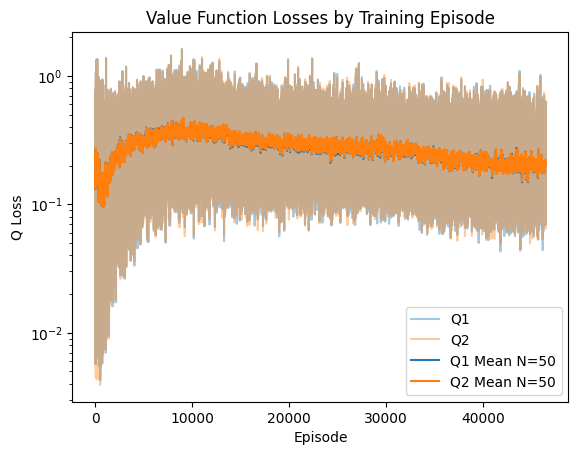

In [34]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

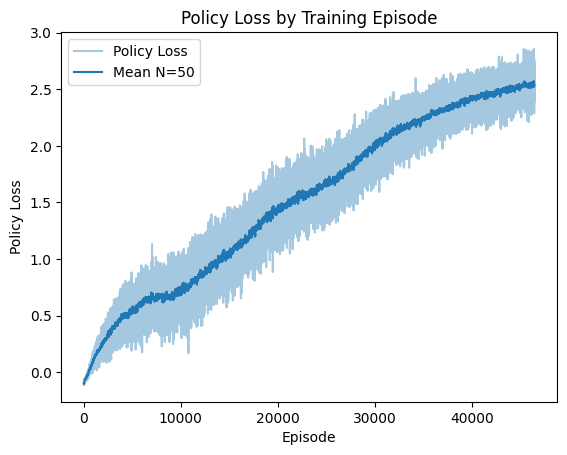

In [35]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

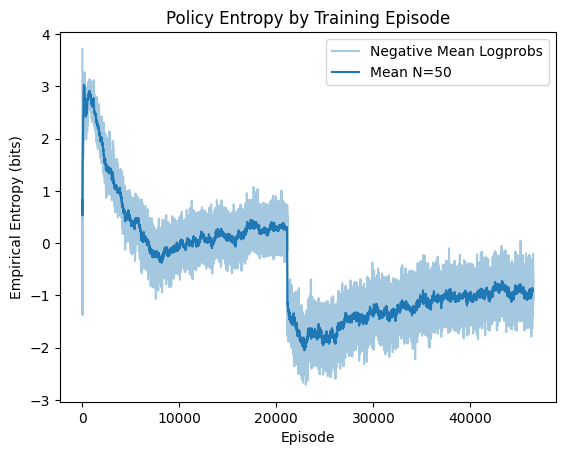

In [36]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

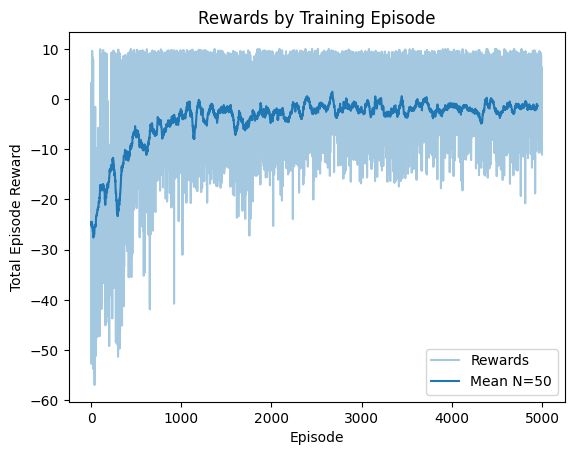

In [37]:
plot_rewards(trainer.logs["Rewards"], "./results")

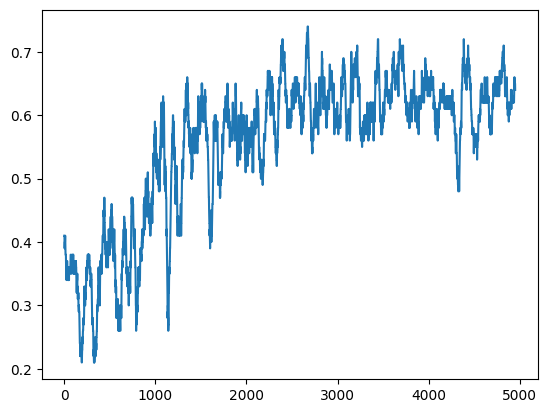

In [38]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

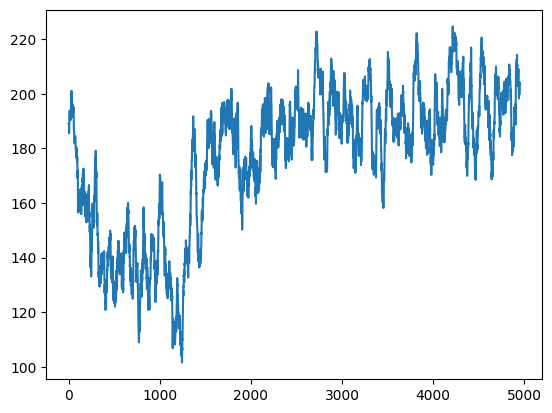

In [39]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

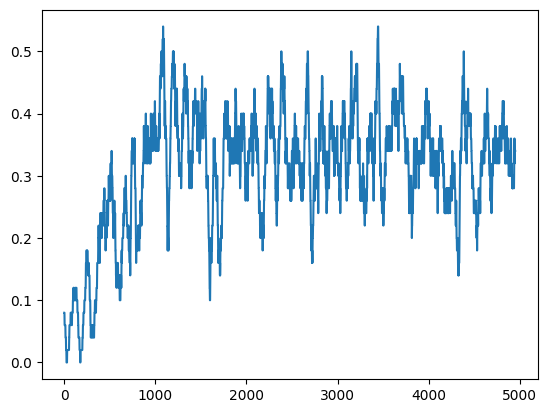

In [40]:
plt.plot(running_mean(np.asarray(trainer.logs["Scores"]) == 1, 50))